# Тест построения графа по данным из OSM 

(полученным от компании NextGIS)

Проблемы:

1. Для использования set_travel_times с дорогами от Next_GIS нужно обязательно указывать поле в котором кхранится тип дороги - `HIGHWAY`
2. При сборке графа для всех частей дроги тупо ставится одно время следования. т.е. если в дороге пять частей, то ее время следование повторяется пять раз и соответсвенно не может быть учтено!

In [1]:
import osmnx as ox
import geopandas as gpd
import networkx as nx

ox.__version__

'2.0.1'

# Загрузка данных

In [171]:
# Загрузка данных о дорогах из файла .gpkg
# highways = gpd.read_file('G:/QGIS/_дороги_Новосибирск/data/highways.gpkg', layer='highways')
highways = gpd.read_file('G:/QGIS/Nsk/data/highways.gpkg', layer='highways')
# highways.plot()

In [198]:
# Загрузка ГДС
import warnings
from graphs.algorithms import graph_rise_from_gpkg
from osmnx import utils
from graphs.speeds import set_graph_travel_times, kmh_to_mm
from fire_units.settings import DEFAULT_SPEEDS
from shapely.geometry import MultiLineString
from shapely.ops import unary_union, transform
import numpy as np



def floor_coords(geoms):
    """Округляет координаты геометрии до целых чисел в меньшую сторону"""
    def floor_coord(x, y):
        #return (math.floor(x), math.floor(y))
        return (round(x, 0), round(y, 0))
    
    return transform(floor_coord, geoms)
    

def graph_rise_from_gpkg2(roads: gpd.GeoDataFrame,
                         oneway_field_name: str = 'oneway',
                         # lanes_field_name: str = 'lanes',  # Сейчас не реализовано
                         reversed_field_name: str = 'reversed',
                         ):
    '''
    Алгоритм собирает граф дорожной сети на основе геометрии входного векторного GeoDataFrame

    Аргументы
    ---------
    `roads`: gpd.GeoDataFrame
        Датафрейм дорог
    `oneway_field_name`: str
        Поле в котором хранятся сведения о односторонности дороги
    `reversed_field_name`: str
        Поле в котором хранятся сведения о направлении движения

    Возвращает
    ----------
    `nx.MultiDiGraph`
        Граф улично-дорожной сети
    ``
    '''
    # Проверка наличия колонок
    #missing_cols = [col for col in [oneway_field_name, reversed_field_name] if col not in roads.columns]
    #if missing_cols:
    #    raise ValueError(f"В GeoDataFrame отсутствуют необходимые колонки: {missing_cols}")

    # Запомним исходную СК
    crs = roads.crs
    
    # Спроектируем DataFrame в местную метрическую систему координат
    try:
        roads_p = ox.projection.project_gdf(roads)
    except Exception:
        roads_p = roads

    # Округляем координаты геометрии до целых чисел
    roads_p['geometry'] = roads_p['geometry'].apply(floor_coords)

    # Создаем пустой граф
    metadata = {
            "created_date": utils.ts(),
            "created_with": f"OSMnx {ox.__version__}",
            "crs": roads_p.crs
        }
    G = nx.MultiDiGraph(**metadata)

    nodes_dict = {}
    node_id = 0

    # Словарь имеющихся ребер (для учета повторов)
    existed_edges_dict = {}

    # Перебираем все строки с записями фрагментов дорог
    for _, road in roads_p.iterrows():
        geometry = road['geometry']

        # Обработка MultiLineString
        # Это нужно проверить
        if isinstance(geometry, MultiLineString):
            lines = geometry.geoms
        else:
            lines = [geometry]

        road_data = road  #[columns_list]
        road_data = {k: v[0] if isinstance(v, list) else v for k, v in road_data.items()}
        del road_data['geometry']

        # print('---общее')
        road_length = 0
        for line in lines:
            coords = list(line.coords)
            for coord1, coord2 in zip(coords[:-1], coords[1:]):
                road_length_cur = ox.distance.euclidean(y1=coord1[1], x1=coord1[0],
                                            y2=coord2[1], x2=coord2[0])
                road_length += road_length_cur
                # print(road_length, road_length_cur)
        # print('======')

        # Добавить интерполирвоание travel_time для каждой линии (А на будущее и иных данных)
        travel_time = road_data.get('travel_time', 0)
        # print(travel_time)
                
        # Перебираем все линии в геометрии (может быть несколько для MultiLineString)
        for line in lines:
            coords = list(line.coords)

            # Добавляем узлы в граф
            for coord in coords:
                if coord not in nodes_dict:
                    nodes_dict[coord] = node_id
                    node_id += 1
                G.add_node(nodes_dict[coord], x=coord[0], y=coord[1])

            # Добавляем ребра в граф
            for coord1, coord2 in zip(coords[:-1], coords[1:]):
                length = ox.distance.euclidean(y1=coord1[1], x1=coord1[0],
                                              y2=coord2[1], x2=coord2[0])
                if travel_time > 0:
                    travel_time_line = travel_time * length / road_length
                    # создаем массив длинн для каждого фрагмента линии
                    road_data['travel_time'] = travel_time_line
                    # print('- ', travel_time_line, length, road_length)


                # Универсальная обработка oneway
                oneway = road_data.get(oneway_field_name, False)
                # Проверка на NaN
                if isinstance(oneway, float) and np.isnan(oneway):
                    oneway = False
                elif isinstance(oneway, str):
                    oneway = oneway.lower() in ['yes', 'true', '1']
                elif isinstance(oneway, (int, float)):
                    oneway = bool(oneway)
                road_data[oneway_field_name] = oneway

                # Универсальная обработка reversed
                reversed_val = road_data.get(reversed_field_name, False)
                if isinstance(reversed_val, float) and np.isnan(reversed_val):
                    reversed_val = False
                elif isinstance(reversed_val, str):
                    reversed_val = reversed_val.lower() in ['yes', 'true', '1']
                elif isinstance(reversed_val, (int, float)):
                    reversed_val = bool(reversed_val)
                road_data[reversed_field_name] = reversed_val

                if not oneway:
                    # Двусторонняя дорога — ребра в обе стороны
                    key = existed_edges_dict.get((nodes_dict[coord2], nodes_dict[coord1]), 0)
                    G.add_edge(nodes_dict[coord2], nodes_dict[coord1], key,
                               **road_data, length=length)
                    existed_edges_dict[(nodes_dict[coord2], nodes_dict[coord1])] = key + 1

                    key = existed_edges_dict.get((nodes_dict[coord1], nodes_dict[coord2]), 0)
                    G.add_edge(nodes_dict[coord1], nodes_dict[coord2], key,
                               **road_data, length=length)
                    existed_edges_dict[(nodes_dict[coord1], nodes_dict[coord2])] = key + 1
                else:
                    # Односторонняя дорога
                    if reversed_val:
                        # Движение в обратном направлении
                        key = existed_edges_dict.get((nodes_dict[coord2], nodes_dict[coord1]), 0)
                        G.add_edge(nodes_dict[coord2], nodes_dict[coord1], key,
                                   **road_data, length=length)
                        existed_edges_dict[(nodes_dict[coord2], nodes_dict[coord1])] = key + 1
                    else:
                        # Движение в прямом направлении
                        key = existed_edges_dict.get((nodes_dict[coord1], nodes_dict[coord2]), 0)
                        G.add_edge(nodes_dict[coord1], nodes_dict[coord2], key,
                                   **road_data, length=length)
                        existed_edges_dict[(nodes_dict[coord1], nodes_dict[coord2])] = key + 1

    # Также вызываем project_graph для перепроецирования геометрии рёбер (если она есть)
    G = ox.projection.project_graph(G, to_crs=crs)

    return G






# ===========================================================================
# Определяем какие столбцы следует оставить в графе
key_fields = ['u', 'v', 'key', 'osmid', 'length']  #, 'travel_time']
columns_list = [col for col in highways.columns if col not in key_fields]

# Создаем граф
print('СК highways', highways.crs)
G = graph_rise_from_gpkg2(highways[columns_list], oneway_field_name='ONEWAY')


# Проверка связности
if nx.is_strongly_connected(G):
    print("✓ Граф является сильно связным")
else:
    print("⚠ Граф не является сильно связным (есть несвязанные компоненты)")
    components = list(nx.strongly_connected_components(G))
    print(f"  Количество компонент связности: {len(components)}")
    largest_component = max(components, key=len)
    print(f"  Размер наибольшей компоненты: {len(largest_component)} узлов")
    
    # Если граф не связный, можно использовать только наибольшую компоненту
    if len(components) > 1:
        print("  Рекомендация: использовать наибольшую компоненту для расчетов")

print(G.graph['crs'])




def set_graph_travel_times2(G: nx.MultiDiGraph,
                     speeds: list,
                     morph_function: callable = None,
                     travel_time_field: str = 'travel_time',
                     speed_field: str = 'maxspeed',
                     highway_speed = 'highway',
                     length_field = 'length',
                     ):
   

    # 0. Проверка входящих данных
    if not isinstance(G, nx.MultiDiGraph):
        raise TypeError('Тип данных аргумента `env` должен быть nx.MultiDiGraph')
    if not isinstance(speeds, list):
        raise ValueError('Тип данных аргумента `speeds` должен быть список')
    if len(speeds) != 5:
        raise ValueError('Аргумент `speeds` должен содержать строго 5 элементов!')

    if G.graph.get('simplified', False):
        warnings.warn("Граф был ранее упрощен! Оценка времени следования такого графа может повлечь неточности. " + \
              "Рекомендуется устанавливать время следования для неупрощенного графа " + \
              "и только после этого упрощать")

    # 1 Перевод скоростей в некоторые значения
    if morph_function is None:
        s1, s2, s3, s4, s5 = speeds
    else:
        s1, s2, s3, s4, s5 = [morph_function(kmh) for kmh in speeds]

    # 2 Установка скоростей для тегов OSM
    sp = {
            "trunk":          s1,           # Важные дороги, не являющиеся автомагистралями
            "trunk_link":     s1,           # Важные дороги, не являющиеся автомагистралями
            "motorway":       s1,           # Автомагистрали 
            "motorway_link":  s1,           # Автомагистрали 

            "primary":        s2,           # Автомобильные дороги регионального значения
            "primary_link":   s2,           # Автомобильные дороги регионального значения
            "secondary":      s2,           # Автомобильные дороги областного значения
            "secondary_link": s2,           # Автомобильные дороги областного значения
            "unclassified":   s2,           # Остальные автомобильные дороги местного значения, образующие соединительную сеть дорог.

            "tertiary":       s3,           # Более важные автомобильные дороги среди прочих автомобильных дорог местного значения
            "tertiary_link":  s3,           # Более важные автомобильные дороги среди прочих автомобильных дорог местного значения
            "residential":    s3,           # Дороги, которые проходят внутри жилых зон, а также используются для подъезда к ним
            "living_street":  s3,           # Жилые зоны и дворовые проезды

            "road":           s4,           # Линии, возможно, являющиеся дорогами. Временный тег, которым следует помечать линии до уточнения.
            "service":        s4,           # Служебные проезды: внутриквартальные, въездные, парковочные и т.д.
            "track":          s4,           # Дороги сельскохозяйственного назначения, лесные дороги, не ведущие к жилым или промышленным объектам, неофициальные грунтовки, козьи тропы

            "footway":        s5,           # Пешеходные дорожки, тротуары. 
            "path":           s5,           # Тропа (чаще всего, стихийная) использующаяся пешеходами, либо одним или несколькими видами транспорта, кроме четырехколесного (лыжи, снегоход, велосипед).
            "pedestrian":     s5,           # Для обозначения улиц городов (такого же класса как residential), выделенных для пешеходов.

            "steps":          s5,           # Лестницы, лестничные пролёты. 
            "cycleway":       s5,           # Велодорожка, обозначенная соответствующим дорожным знаком. 
            "bridleway":      s5,           # Дорожки для верховой езды.
            "corridor":       s5,           # Коридоры внутри крупных зданий
            "other":          s5,           # Все прочие - неопознанные
        }

    # 3. расчет и установка времени следования и скоростей
    attributes = {}
    for edge in G.edges:
        road = G.get_edge_data(*edge).get(highway_speed, 'other')
        length = G.get_edge_data(*edge).get(length_field)
        if isinstance(road, list):
            road_speeds = [sp.get(rf, s5) for rf in road]
            speed       = sum(road_speeds) / len(road_speeds)
        else:
            speed  = sp.get(road, s5)
            # print(road, speed)

        weight = length/speed
        attributes[*edge] = {travel_time_field: weight, speed_field: speed}

    nx.set_edge_attributes(G, attributes)

# set_graph_travel_times2(G, DEFAULT_SPEEDS, kmh_to_mm, highway_speed='HIGHWAY')

СК highways EPSG:4326
⚠ Граф не является сильно связным (есть несвязанные компоненты)
  Количество компонент связности: 240
  Размер наибольшей компоненты: 183939 узлов
  Рекомендация: использовать наибольшую компоненту для расчетов
EPSG:4326


185452 398111
183939 395384


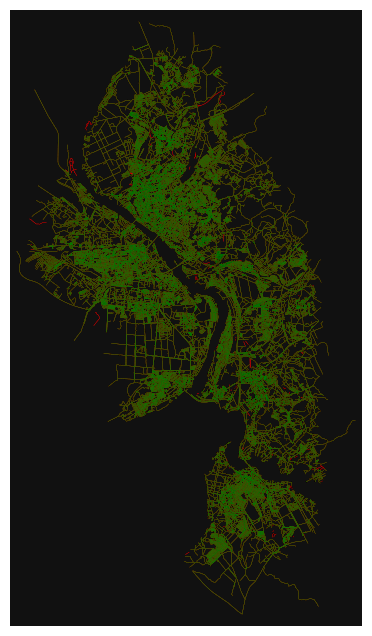

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [200]:
largest_component = max(components, key=len)

GC = G.subgraph(largest_component)
print(G.number_of_nodes(), G.number_of_edges())
print(GC.number_of_nodes(), GC.number_of_edges())
fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.2, close=False, show=False, edge_color='r')
ox.plot_graph(GC, ax=ax, node_size=0, edge_linewidth=0.2, edge_color='g')

In [201]:
# Загрузка данных о зданиях
buildings = gpd.read_file('G:/QGIS/Nsk/data/buildings.gpkg', layer='buildings')
### Сопоставление зданий с ближайшими узлами ГДС
### Для полигональных объектов следует использовать центроиды: `geometry.centroid`
### Наборы данных желательно перепроецировать в локальную СК
centroids = ox.projection.project_gdf(buildings).geometry.centroid
buildings['node'], buildings['dist'] = ox.distance.nearest_nodes(ox.project_graph(G), 
                                              centroids.x,
                                              centroids.y,
                                              return_dist = True,
                                              )

In [202]:
## Загрузка пожарных подразделений
units = gpd.read_file('G:/QGIS/Nsk/fire_data/units.gpkg', layer='Подразделения')
print(units.crs)
### Сопоставление пожарных подразделений с ближайшими узлами ГДС
units['node'] = ox.distance.nearest_nodes(G, units.geometry.x, units.geometry.y)
### Формирование словаря подразделений для передачи алгоритму
units_dict = {k:v for k,v in zip(units['node'], units['name'])}

EPSG:4326


# Тесты

In [203]:
ox.graph_to_gdfs(G, nodes=False).head()

NAME      HIGHWAY MAXSPEED OSM_TYPE    OSM_ID  \
u v      key                                                                
0 1      0    Ядринцевская улица  residential   433.33      way  25642954   
  9721   0       Каменская улица     tertiary   433.33      way  95212567   
  184575 0    Ядринцевская улица  residential   433.33      way  25754453   
1 0      0    Ядринцевская улица  residential   433.33      way  25642954   
  2      0    Ядринцевская улица  residential   433.33      way  25642954   

              travel_time  reversed     length ONEWAY LANES  SURFACE NAME_EN  \
u v      key                                                                   
0 1      0       0.021243     False   9.219544    NaN   NaN      NaN     NaN   
  9721   0       0.018610     False   8.062258   True     2  asphalt     NaN   
  184575 0       0.020920     False   9.055385    NaN   NaN      NaN     NaN   
1 0      0       0.021243     False   9.219544    NaN   NaN      NaN     NaN   
  2      0       0.074628     False  32.388269    NaN   NaN      NaN     NaN   

             NAME_RU  REF BRIDGE TUNNEL WIDTH  \
u v      key                                    
0 1      0       NaN  NaN    NaN    NaN   NaN   
  9721   0       NaN  NaN    NaN    NaN   NaN   
  184575 0       NaN  NaN    NaN    NaN   NaN   
1 0      0       NaN  NaN    NaN    NaN   NaN   
  2      0       NaN  NaN    NaN    NaN   NaN   

                                                       geometry  
u v      key                                                     
0 1      0     LINESTRING (82.92755 55.03353, 82.9277 55.03355)  
  9721   0     LINESTRING (82.92755 55.03353, 82.92754 55.0336)  
  184575 0    LINESTRING (82.92755 55.03353, 82.92741 55.03352)  
1 0      0     LINESTRING (82.9277 55.03355, 82.92755 55.03353)  
  2      0      LINESTRING (82.9277 55.03355, 82.9282 55.03358)

## Расчет прикрытых зданий

In [204]:
times, _ = FirstArrivalUnitState()(env=G, points=units_dict)
times

132561     1.000000
128983     1.000000
139241     1.000000
131874     1.000000
73648      1.000000
            ...    
77952     66.111645
77953     67.438184
77954     67.896054
77955     68.457311
77956     68.855545
Name: times, Length: 183990, dtype: float64

In [205]:
# Расчет не прикрытых зданий
import matplotlib.pyplot as plt
from genesis.states import FirstArrivalUnitState


times, _ = FirstArrivalUnitState()(env=G, points=units_dict)
times = times[times>10]
print('Узлов не прикрыто', len(times), 'из', G.number_of_nodes())
buildings_not_covered = buildings.query(f'node in {list(times.keys())}')
print('Не прикрыто зданий:', len(buildings_not_covered), 'из', len(buildings))


Узлов не прикрыто 79411 из 185452
Не прикрыто зданий: 32056 из 108280


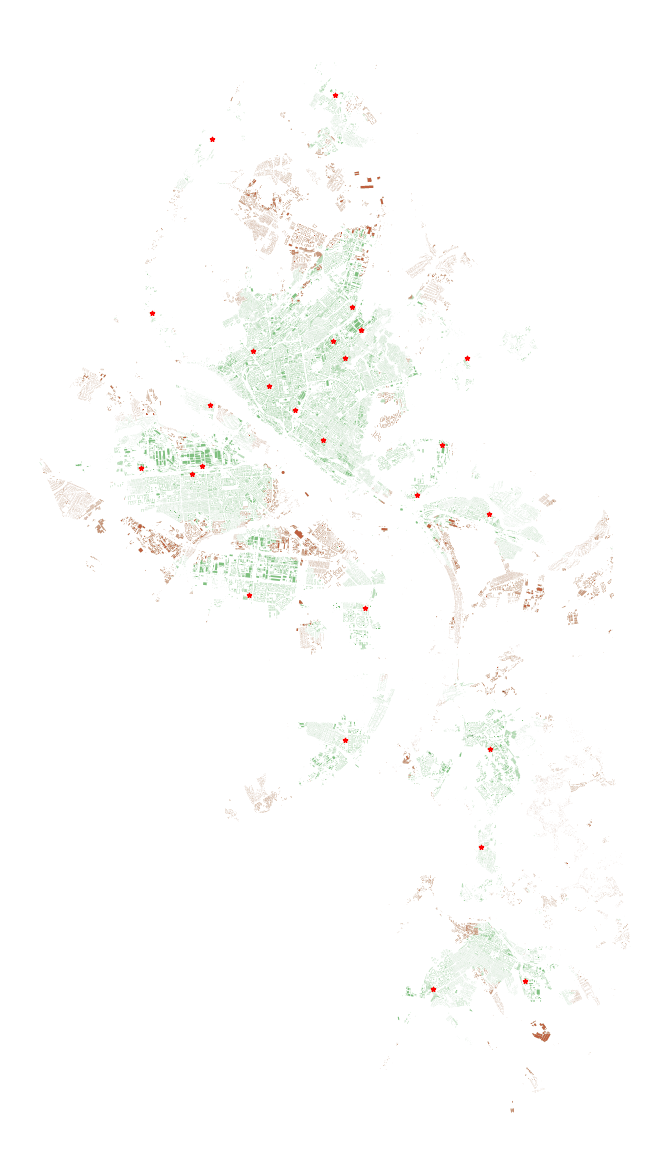

In [206]:
# Печать результата
fig, ax = plt.subplots(figsize=(15, 15))
buildings.plot(ax=ax, color='green', alpha=0.5)
buildings_not_covered.plot(ax=ax, color='red', alpha=0.5)
units.plot(ax=ax, markersize=10, color='red', marker='*')
ax.set_axis_off()
plt.show()
